In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
import seaborn as sns
import PyMieScatt as ps
from scipy.stats import linregress
from shapely.geometry import LineString
#!python -m pip install <nome_do_pacote>

Arrumando os dados

In [23]:
# Leitura dos dados
smps = pd.read_csv('data/campinas/Campinas-2017_SMPS_TSI_3082_Level3_30min.csv', header=1,sep=';')

smps = smps[smps[' Total concentration Mean (cm-3)']!= ' NaN']#remove linhas com valores nulos na coluna
smps = smps.drop(' ', axis=1)
smps = smps.reset_index()

time= pd.to_datetime(smps[' UnixTime(UTC)'],unit='s')
smps = smps.drop('Time(UTC)', axis=1)
smps['Time(UTC)'] = time
# Definindo a coluna de nefe e hora como índice
smps.set_index('Time(UTC)', inplace=True)

for column in smps.columns:
    smps['%s'%(column)] = smps['%s'%(column)].astype(float)

smps = smps.fillna(0)

smps.index = smps.index - timedelta(hours=3)
smps.index.name = 'Time(UTC) - 3'

In [3]:
#SÓ RODAR UMA VEZ

colunas_vazias = ["scat637 Mean (Mm-1)", "Abs637 Mean (Mm-1)"]

# Cria um DataFrame temporário com colunas vazias
df_vazio = pd.DataFrame(
    {col: np.nan for col in colunas_vazias},  # Dicionário com nomes e valores vazios
    index=smps.index  # Garante o mesmo índice que o DataFrame original
)

# Concatena com o DataFrame original
smps = pd.concat([smps, df_vazio], axis=1)  # axis=1 para colunas

Cálculo dos coeficientes com a biblioteca PyMieScatt

In [4]:
# "Desnormalizando" a distribuição
sizeDistributionDiameterBins = smps.columns[5:-2].tolist() #exclui as 5 primeiras colunas e as duas ultimas
sizeDistributionDiameterBins = [float(x) for x in sizeDistributionDiameterBins]

listasDlogs = []
for i in range(len(sizeDistributionDiameterBins) - 1):
    dlogi = np.log(sizeDistributionDiameterBins[i+1]) - np.log(sizeDistributionDiameterBins[i])
    listasDlogs.append(dlogi)

dlog = np.mean(listasDlogs) #media dos dlogs(Dp) da distribuição

In [5]:
m3 = 1.50 + 0.02j
wavelength = 637 #nm
Bsca = []
Babs = []


for i in range(len(smps)):
    sizeDistributionDiameterBins = smps.columns[5:-2].tolist() #exclui as 5 primeiras colunas e as duas ultimas

    sizeDistribution = np.array(smps[sizeDistributionDiameterBins].astype(float).values.tolist()[i])*dlog 
    #sizeDistribution = np.full(len(sizeDistributionDiameterBins), smps[' Total concentration Mean (cm-3)'][i])*dlog 

    sizeDistributionDiameterBins = [float(x) for x in sizeDistributionDiameterBins]

    resultado = ps.Mie_SD(m3, wavelength, sizeDistributionDiameterBins, sizeDistribution,nMedium=1.0, SMPS=True, asDict=True)
    smps.at[smps.index[i],'scat637 Mean (Mm-1)'] = resultado['Bsca']
    smps.at[smps.index[i],'Abs637 Mean (Mm-1)'] = resultado['Babs']


Bsca =  smps['scat637 Mean (Mm-1)']
Babs =  smps['Abs637 Mean (Mm-1)'] 

KeyboardInterrupt: 

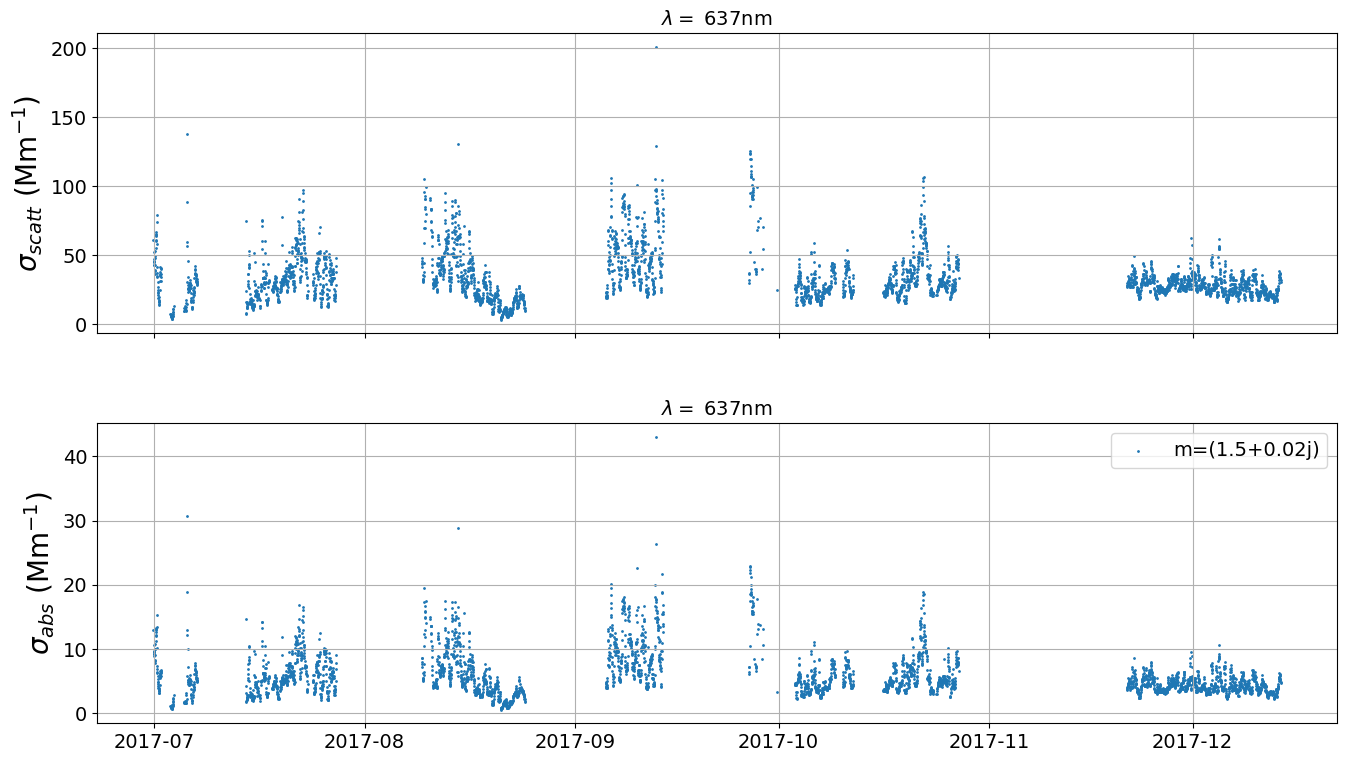

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10),sharex=True)
dados = [
    (smps.index, Bsca, r'$\sigma_{scatt}$ (Mm$^{-1}$)','Espalhamento'),
    (smps.index, Babs, r'$\sigma_{abs}$ (Mm$^{-1}$)','Absorção'),
] 

# Loop para plotar os gráficos com períodos diferenciados por cor
for i, (ax, (x, y, ylabel, title)) in enumerate(zip(axes.ravel(), dados)):
    ax.scatter(x, y,s=1,label=f'm={m3}')
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid()
    ax.set_title(rf'$\lambda = $ {wavelength}nm',fontsize=14)

    # Adiciona a legenda apenas no primeiro gráfico
    if i != 0:
        ax.legend(fontsize=14)

# Ajuste dos labels no eixo x do último subplot
axes[-1].tick_params(axis='x', labelsize=14)
plt.subplots_adjust(hspace=0.3, top=0.8)

plt.show()

### Comparação com as medidas

In [6]:
nefe = pd.read_csv('data/campinas/Campinas-2017_Nephelometer_Aurora_Ecotech_3000_Level3_5min.csv', sep='; ', header=1)

nefe = nefe[nefe['scat450 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna
nefe = nefe[nefe['scat525 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna
nefe = nefe[nefe['scat635 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna  
nefe = nefe.dropna()
nefe = nefe.reset_index()

time= pd.to_datetime(nefe['UnixTime(UTC)'],unit='s')
nefe = nefe.drop('Time(UTC)', axis=1)
nefe['Time(UTC)'] = time
# Definindo a coluna de nefe e hora como índice
nefe.set_index('Time(UTC)', inplace=True)

for column in nefe.columns:
    nefe['%s'%(column)] = nefe['%s'%(column)].astype(float)

#nefe = nefe[nefe['scat525 Mean (Mm-1)'] <= 900]#remove linhas com valores nulos na coluna
nefe.index = nefe.index - timedelta(hours=3)
nefe.index.name = 'Time(UTC) - 3'

/tmp/ipykernel_15857/2343954547.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  nefe = pd.read_csv('data/campinas/Campinas-2017_Nephelometer_Aurora_Ecotech_3000_Level3_5min.csv', sep='; ', header=1)


In [7]:
#Interpolação e SAE
# Separando os valores para o gráfico
orange = nefe['scat635 Mean (Mm-1)']
green = nefe['scat525 Mean (Mm-1)']
blue = nefe['scat450 Mean (Mm-1)']

nefe['scat637 Mean (Mm-1)'] = np.nan
nefe['SAE'] = np.nan
nefe['sigma_SAE'] = np.nan

lambdas = [635,525,450]
for i in range(len(nefe)):
    sigma = [orange[i],green[i],blue[i]]
    coeff, cov_matrix = np.polyfit(np.log(lambdas),np.log(sigma), 1,cov= True)
    nefe.at[nefe.index[i], 'SAE'] = -coeff[0]
    sigmaSAE = np.sqrt(cov_matrix[0, 0])
    scat637i = np.exp(coeff[0]*np.log(637) + coeff[1])
    nefe.at[nefe.index[i], 'scat637 Mean (Mm-1)'] = scat637i
    nefe.at[nefe.index[i], 'sigma_SAE'] = sigmaSAE

In [9]:
aet = pd.read_csv('data/campinas/Campinas_Aethalometer_AE33_Level2_5min.csv', encoding='latin-1',header=1,sep=';')
aet = aet.dropna(subset=[' abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna

time= pd.to_datetime(aet[' UnixTime(UTC)'],unit='s')
aet = aet.drop('Time(UTC)', axis=1)
aet['Time(UTC)'] = time
aet.set_index('Time(UTC)', inplace=True)

for column in aet.columns:
   aet['%s'%(column)] = aet['%s'%(column)].astype(float)
#aet = aet[aet[' abs637 Mean (Mm-1)'] >=0]


aet = aet.dropna(subset=[' abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna
aet = aet.drop(' ',axis=1)
aet.index = aet.index - timedelta(hours=3)
aet.index.name = 'Time(UTC) - 3'

In [10]:
maap = pd.read_csv('data/campinas/Campinas-2017_MAAP_5012_Level3_5min.csv', encoding='latin-1',header=1,sep=';')
maap = maap.dropna(subset=[' Abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna

time= pd.to_datetime(maap[' UnixTime(UTC)'],unit='s')
maap = maap.drop('Time(UTC)', axis=1)
maap['Time(UTC)'] = time
maap.set_index('Time(UTC)', inplace=True)

for column in maap.columns:
   maap['%s'%(column)] = maap['%s'%(column)].astype(float)
#maap = maap[maap[' Abs637 Mean (Mm-1)'] >=0]


maap = maap.dropna(subset=[' Abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna
maap = maap.drop(' ',axis=1)
maap.index = maap.index - timedelta(hours=3)
maap.index.name = 'Time(UTC) - 3'

Intersecção

usando o aet

In [26]:
nefe_intersec = nefe.resample('30min').mean()
aet_intersec = aet.resample('30min').mean()
smps_intersec  = smps.resample('30min').mean()

smps_intersec  = smps_intersec.dropna()
aet_intersec = aet_intersec.dropna()
nefe_intersec = nefe_intersec.dropna()

indices_comuns_aet = smps_intersec.index.intersection(aet_intersec.index).intersection(nefe_intersec.index)
smps_intersec_aet = smps_intersec.loc[indices_comuns_aet]
aet_intersec  = aet_intersec.loc[indices_comuns_aet]
nefe_intersec_aet  = nefe_intersec.loc[indices_comuns_aet]

len(indices_comuns_aet)

5766

usando o maap

In [24]:
nefe_30_min = nefe.resample('30min').mean().dropna()
maap_30_min= maap.resample('30min').mean().dropna()
smps_30_min  = smps.resample('30min').mean().dropna()


indices_comuns = smps_30_min.index.intersection(maap_30_min.index).intersection(nefe_30_min.index)
smps_intersec = smps_30_min.loc[indices_comuns]
maap_intersec  = maap_30_min.loc[indices_comuns]
nefe_intersec  = nefe_30_min.loc[indices_comuns]

print(len(indices_comuns))

6534


KeyError: 'scat637 Mean (Mm-1)'

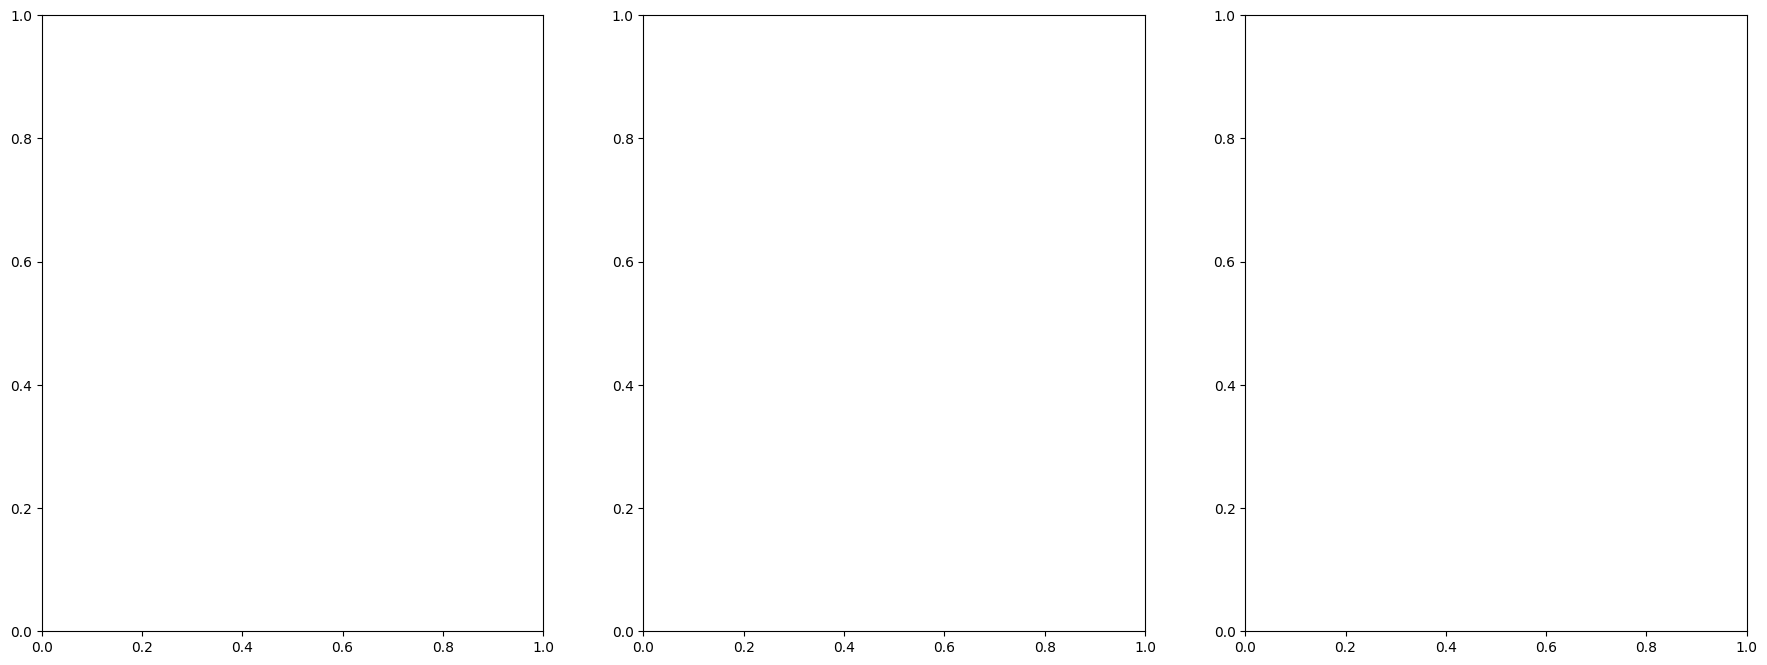

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
dados = [
    (smps_intersec['scat637 Mean (Mm-1)'], nefe_intersec['scat637 Mean (Mm-1)'], r'$\sigma_{scatt}$ (Mm$^{-1}$)','Espalhamento','Nefelômetro'),
    (smps_intersec['Abs637 Mean (Mm-1)'] , maap_intersec[' Abs637 Mean (Mm-1)'], r'$\sigma_{abs}$ (Mm$^{-1}$)','Absorção','MAAP'),
    (smps_intersec_aet['Abs637 Mean (Mm-1)'] , aet_intersec[' abs637 Mean (Mm-1)'], r'$\sigma_{abs}$ (Mm$^{-1}$)','Absorção','Aetalômetro'),

] 

# Loop para plotar os gráficos com períodos diferenciados por cor
for i, (ax, (x, y, ylabel, title,equipamento)) in enumerate(zip(axes.ravel(), dados)):
    ax.scatter(x, y,s=1)
    ax.set_ylabel(equipamento, fontsize=18)
    ax.set_xlabel('PyMieScatt', fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid()
    #ax.set_title(rf'{ylabel} em $\lambda = $ {wavelength}nm (Diadema)',fontsize=14)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    y_pred = slope * x + intercept
    ax.plot(x,y_pred,color='red',label=f'$R^2$ = {r_value:.3f}')

    ax.legend( fontsize=16)
#plt.subplots_adjust(hspace=0.3, top=0.8)

plt.show()

Os valores negativos do aet são cerca de 20% dos dados totais, eles devem ser removidos?

### 11/06/2025

Média total e método inverso

In [27]:
def metodoInversoCampinas(
    n_min=1.1, 
    n_max=1.5, 
    n_points=50,
    k_min=0.01, 
    k_max=0.5, 
    k_points=50,
    wavelength=None,
    smps_media_total=None,
    smps=None,
    nefe_media_total=None,
    maap_media_total=None,
    dlog=None,
    show_3d_plots=True,
    show_contour_plot=True,
    find_intersections=True
):
    """
    Função completa para análise Mie e visualização dos resultados.
    
    Parâmetros:
    -----------
    n_min, n_max, n_points: limites e número de pontos para parte real do índice de refração
    k_min, k_max, k_points: limites e número de pontos para parte imaginária do índice de refração
    wavelength: comprimento de onda em nm
    smps_media_chuvoso_total: dados de distribuição de tamanho para condições chuvosas
    smps: dataframe SMPS com informações de tamanho de partícula
    nefe_media_chuvoso_total: dados NEFE para condições chuvosas
    maap_media_chuvoso_total: dados MAAP para condições chuvosas
    dlog: intervalo logarítmico para cálculo da distribuição de tamanho
    show_3d_plots: bool, mostra plots 3D se True
    show_contour_plot: bool, mostra plot de contorno se True
    find_intersections: bool, calcula interseções se True
    
    Retorna:
    --------
    Dicionário com resultados (Bscat, Babs, interseções, etc.)
    """
    
    # 1. Configuração da malha n-k
    n_values = np.linspace(n_min, n_max, n_points)
    k_values = np.linspace(k_min, k_max, k_points)
    n_grid, k_grid = np.meshgrid(n_values, k_values, indexing='ij')
    
    # 2. Inicialização das matrizes de resultados
    Bscat_results = np.zeros_like(n_grid, dtype=np.float64)
    Babs_results = np.zeros_like(n_grid, dtype=np.float64)
    
    # 3. Cálculos Mie para cada ponto da malha
    sizeDistributionDiameterBins = smps.columns[5:-2].tolist()
    sizeDistribution = smps_media_total.values[5:-2] * dlog
    sizeDistributionDiameterBins = [float(x) for x in sizeDistributionDiameterBins]
    
    for i in range(len(n_values)):
        for j in range(len(k_values)):
            m = n_values[i] + 1j * k_values[j]
            resultado = ps.Mie_SD(m, wavelength, sizeDistributionDiameterBins, 
                                 sizeDistribution, nMedium=1.0, SMPS=True, asDict=True)
            Bscat_results[i, j] = resultado['Bsca']
            Babs_results[i, j] = resultado['Babs']
    
    # 4. Níveis para curvas de nível
    level_scatt = nefe_media_total.iloc[7]
    level_abs = maap_media_total.iloc[2]
    
    # 5. Visualização 3D (opcional)
    if show_3d_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})
        
        for ax, data, title, ang_azim, level in zip(
            [ax1, ax2], 
            [Bscat_results, Babs_results], 
            [r'$B_{scatt}$', r'$B_{abs}$'],
            [120, 200], 
            [level_scatt, level_abs]
        ):
            surf = ax.plot_surface(n_grid, k_grid, data, edgecolor='none', alpha=0.5)
            offset = np.min(data) - 0.1 * (np.max(data) - np.min(data))
            ax.contour(n_grid, k_grid, data, zdir='z', offset=offset, 
                       linewidths=2.0, linestyles='solid', levels=[level])
            
            ax.view_init(elev=30, azim=ang_azim)
            ax.set_xlabel('n', fontsize=16)
            ax.set_ylabel('k', fontsize=16)
            ax.set_zlabel(title, fontsize=20)
            ax.set_title(rf'$\lambda$ = {wavelength} nm', fontsize=14)
        
        plt.tight_layout()
        plt.show()
    
    # 6. Visualização de contorno 2D (opcional)
    if show_contour_plot:
        #plt.figure(figsize=(10, 8))
        
        cs1 = plt.contour(n_grid, k_grid, Bscat_results, levels=[level_scatt],
                         colors='red', linewidths=2.0, linestyles='solid')
        
        cs2 = plt.contour(n_grid, k_grid, Babs_results, levels=[level_abs],
                         colors='blue', linewidths=2.0, linestyles='solid')
        
        plt.clabel(cs1, fontsize=12, fmt='%.3f', inline=True)
        plt.clabel(cs2, fontsize=12, fmt='%.3f', inline=True)
        
        plt.xlabel('n', fontsize=16)
        plt.ylabel('k', fontsize=16)
        plt.title(rf'$\lambda$ = {wavelength} nm', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # 7. Cálculo de interseções (opcional)
    intersections = []
    if find_intersections and show_contour_plot:
        paths_cs1 = cs1.allsegs[0]
        paths_cs2 = cs2.allsegs[0]
        
        lines_cs1 = [LineString(segment) for segment in paths_cs1]
        lines_cs2 = [LineString(segment) for segment in paths_cs2]
        
        for line1 in lines_cs1:
            for line2 in lines_cs2:
                intersection = line1.intersection(line2)
                if not intersection.is_empty:
                    if intersection.geom_type == 'Point':
                        intersections.append((intersection.x, intersection.y))
                    elif intersection.geom_type == 'MultiPoint':
                        for point in intersection.geoms:
                            intersections.append((point.x, point.y))
        
        if intersections:
            intersections = np.unique(np.array(intersections), axis=0)
            print("Pontos de interseção (n, k):")
            print(intersections)
        else:
            print("Nenhuma interseção encontrada.")
    
    # 8. Retornar resultados em um dicionário
    results = {
        'n_grid': n_grid,
        'k_grid': k_grid,
        'Bscat_results': Bscat_results,
        'Babs_results': Babs_results,
        'level_scatt': level_scatt,
        'level_abs': level_abs,
        'intersections': intersections
    }
    
    return results

In [28]:
smps_media_total = smps_intersec.mean()
nefe_media_total = nefe_intersec.mean()
#aet_media_total = aet_intersec.mean()
maap_media_total = maap_intersec.mean()

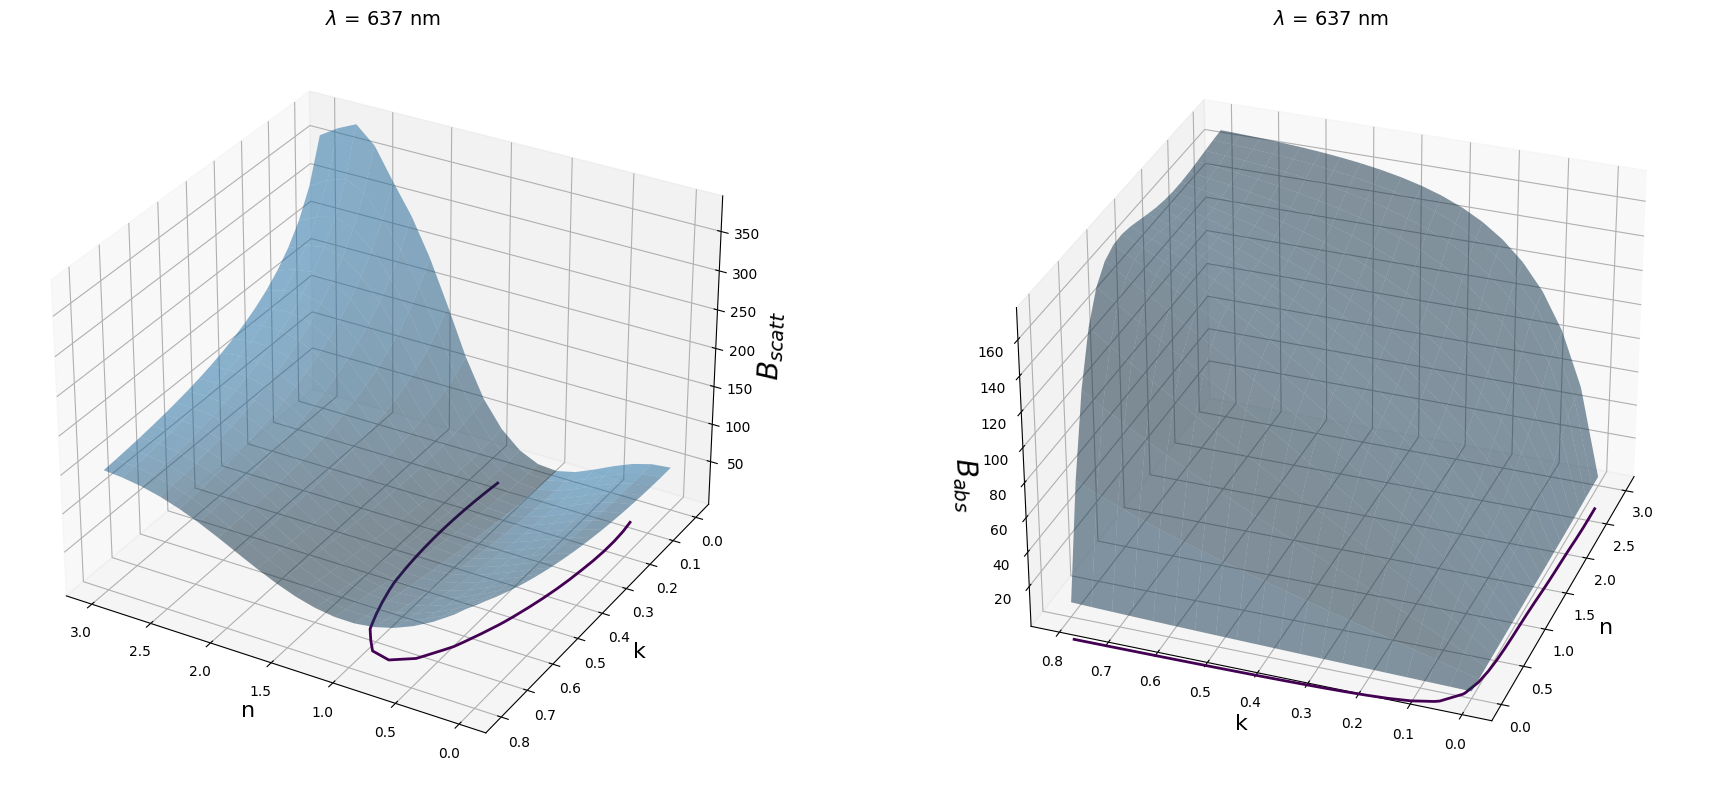

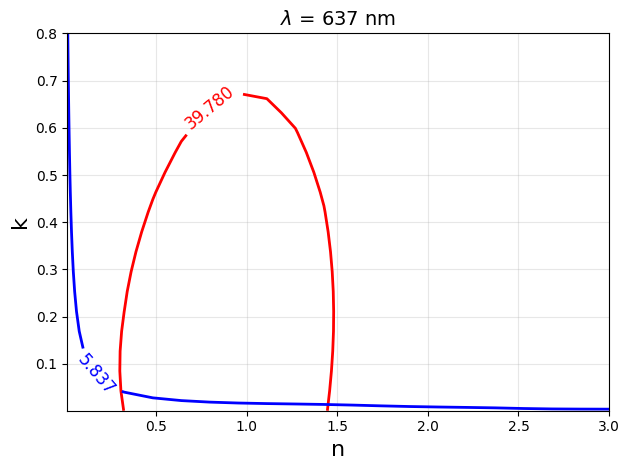

Pontos de interseção (n, k):
[[0.30615656 0.0426664 ]
 [1.44922029 0.01408937]]


In [29]:
resultados = metodoInversoCampinas(
    n_min=0.01,
    n_max=3.0,
    n_points=20,
    k_min=0.001,
    k_max=0.8,
    k_points=20,
    wavelength=637,  # nm
    smps_media_total=smps_media_total,
    smps=smps,
    nefe_media_total=nefe_media_total,
    maap_media_total=maap_media_total,
    dlog=dlog,
    show_3d_plots=True,
    show_contour_plot=True,
    find_intersections=True
)

## Estações do ano

In [31]:
from datetime import datetime
estacoes= [['primavera',"2017-09-22 00:00:00","2017-12-20 00:00:00"] ]

start_primavera= "2017-09-01 00:00:00"
start_primavera = datetime.strptime(start_primavera, "%Y-%m-%d %H:%M:%S")

end_primavera= "2017-11-30 23:59:59"
end_primavera = datetime.strptime(end_primavera , "%Y-%m-%d %H:%M:%S")


start_verao = "2017-12-01 00:00:00"
start_verao = datetime.strptime(start_verao, "%Y-%m-%d %H:%M:%S")

end_verao = "2018-02-28 23:59:59"
end_verao = datetime.strptime(end_verao, "%Y-%m-%d %H:%M:%S")


start_outono = "2018-03-01 00:00:00"
start_outono = datetime.strptime(start_outono, "%Y-%m-%d %H:%M:%S")

end_outono= "2018-05-30 23:59:59"
end_outono = datetime.strptime(end_outono, "%Y-%m-%d %H:%M:%S")


start_inverno = "2017-06-25 00:00:00"
start_inverno = datetime.strptime(start_inverno, "%Y-%m-%d %H:%M:%S")

end_inverno = "2017-08-31 23:59:59"
end_inverno = datetime.strptime(end_inverno, "%Y-%m-%d %H:%M:%S")

### Verão

In [32]:
nefe_verao = nefe.loc[start_verao:end_verao]
maap_verao = maap.loc[start_verao:end_verao]
smps_verao = smps.loc[start_verao:end_verao]

nefe_intersec_verao = nefe_verao.resample('30min').mean()
maap_intersec_verao = maap_verao.resample('30min').mean()
smps_verao  = smps_verao.dropna()
maap_intersec_verao = maap_intersec_verao.dropna()
nefe_intersec_verao = nefe_intersec_verao.dropna()

indices_comuns_verao = smps_verao.index.intersection(maap_intersec_verao.index).intersection(nefe_intersec_verao.index)
len(indices_comuns_verao)
smps_intersec_verao = smps_verao.loc[indices_comuns_verao]
maap_intersec_verao  = maap_intersec_verao.loc[indices_comuns_verao]
nefe_intersec_verao  = nefe_intersec_verao.loc[indices_comuns_verao]

smps_media_verao_total = smps_intersec_verao.mean()
nefe_media_verao_total = nefe_intersec_verao.mean()
maap_media_verao_total = maap_intersec_verao.mean()

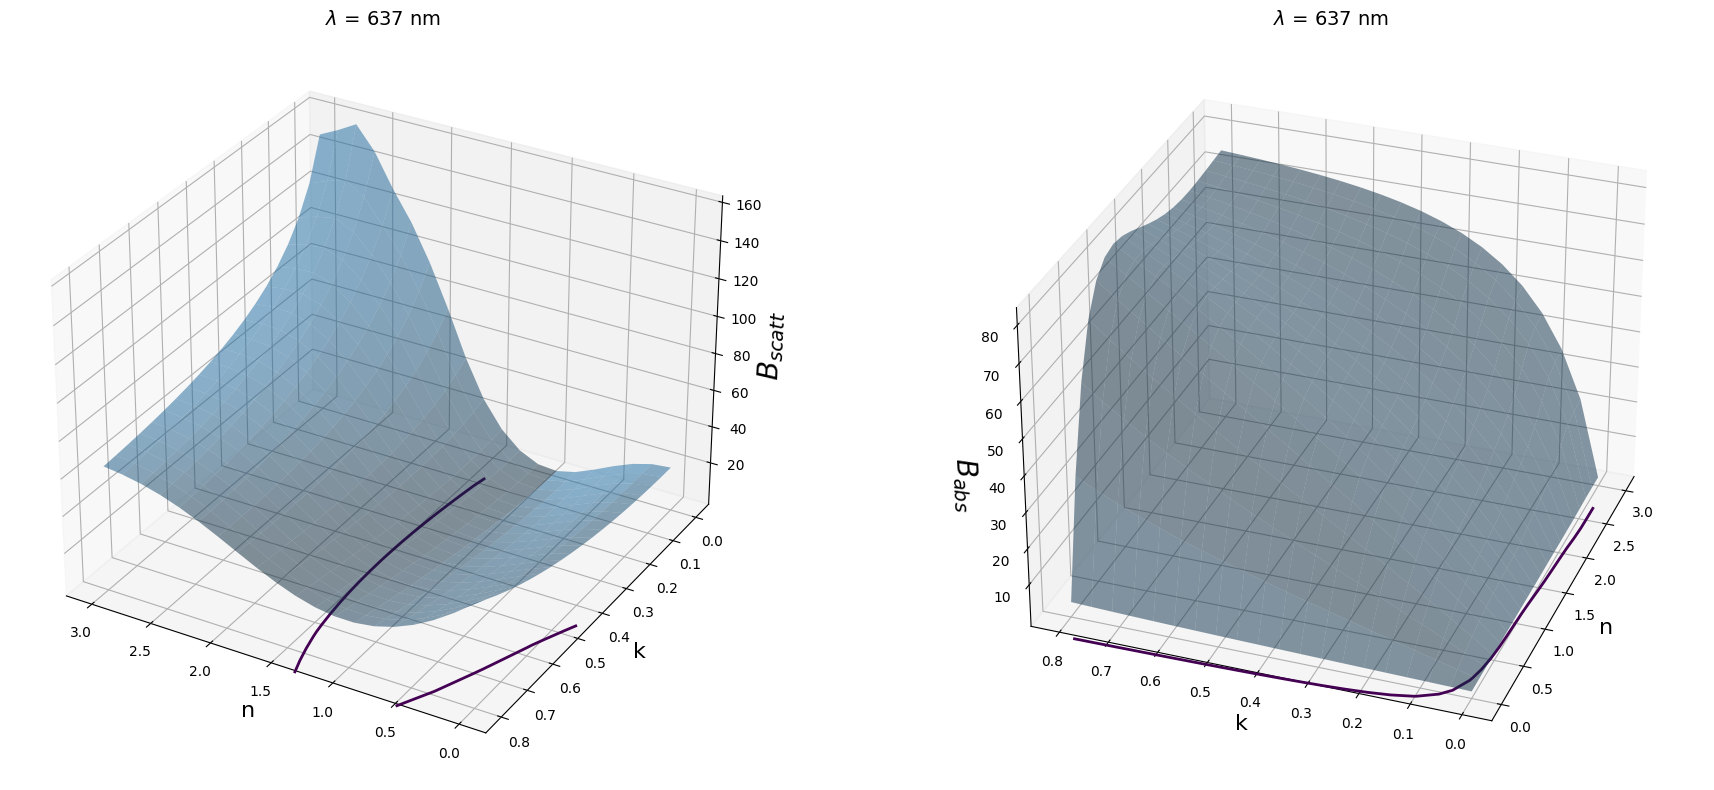

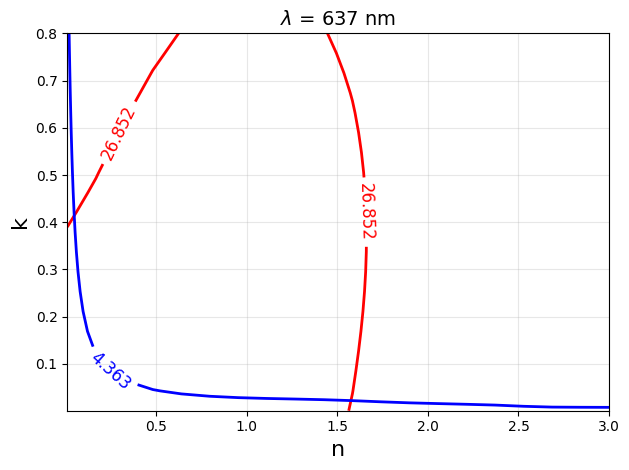

Pontos de interseção (n, k):
[[0.04840141 0.41397789]
 [1.57546826 0.02245042]]


In [33]:
resultados_verao = metodoInversoCampinas(
    n_min=0.01,
    n_max=3.0,
    n_points=20,
    k_min=0.001,
    k_max=0.8,
    k_points=20,
    wavelength=637,  # nm
    smps_media_total=smps_media_verao_total,
    smps=smps,
    nefe_media_total=nefe_media_verao_total,
    maap_media_total=maap_media_verao_total,
    dlog=dlog,
    show_3d_plots=True,
    show_contour_plot=True,
    find_intersections=True
)

### Inverno

In [34]:
nefe_inverno = nefe.loc[start_inverno:end_inverno]
maap_inverno = maap.loc[start_inverno:end_inverno]
smps_inverno = smps.loc[start_inverno:end_inverno]

nefe_intersec_inverno = nefe_inverno.resample('30min').mean()
maap_intersec_inverno = maap_inverno.resample('30min').mean()
smps_inverno  = smps_inverno.dropna()
maap_intersec_inverno = maap_intersec_inverno.dropna()
nefe_intersec_inverno = nefe_intersec_inverno.dropna()

indices_comuns_inverno = smps_inverno.index.intersection(maap_intersec_inverno.index).intersection(nefe_intersec_inverno.index)
len(indices_comuns_inverno)
smps_intersec_inverno = smps_inverno.loc[indices_comuns_inverno]
maap_intersec_inverno  = maap_intersec_inverno.loc[indices_comuns_inverno]
nefe_intersec_inverno  = nefe_intersec_inverno.loc[indices_comuns_inverno]

smps_media_inverno_total = smps_intersec_inverno.mean()
nefe_media_inverno_total = nefe_intersec_inverno.mean()
maap_media_inverno_total = maap_intersec_inverno.mean()

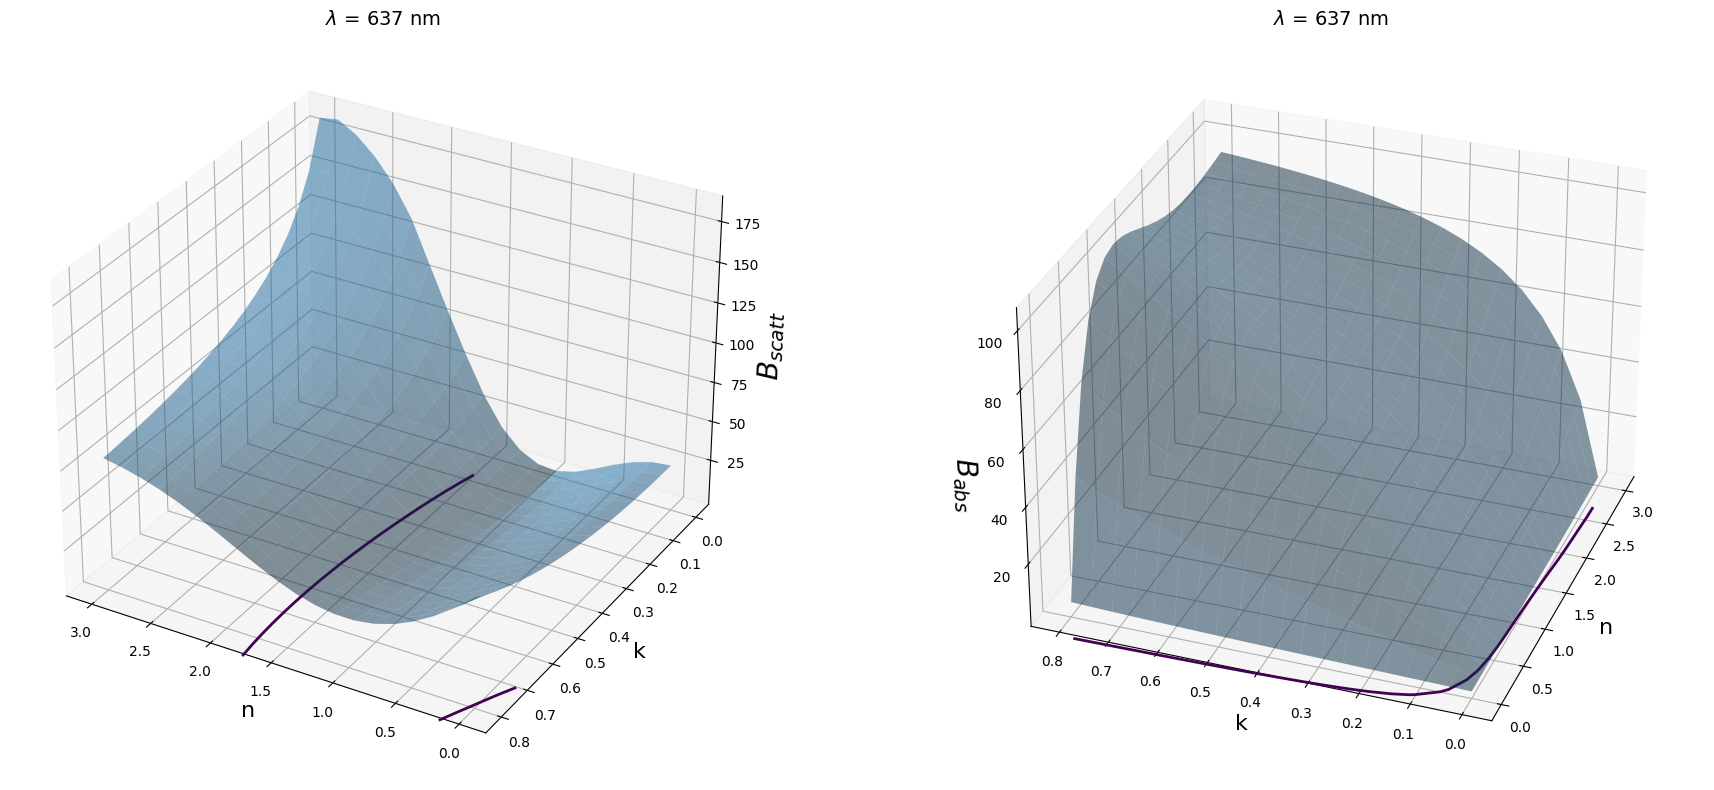

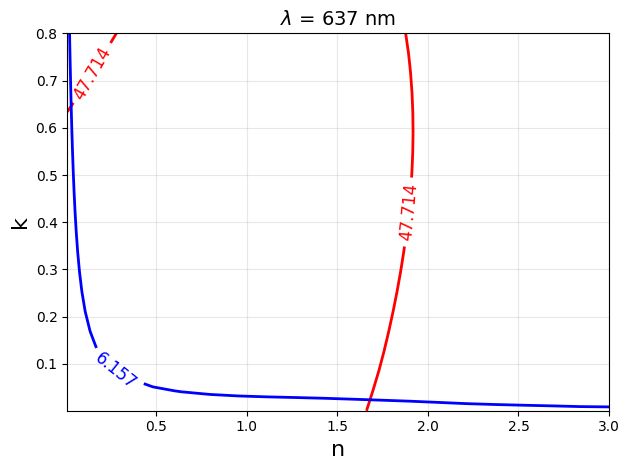

Pontos de interseção (n, k):
[[0.03157064 0.64606379]
 [1.68069151 0.02414136]]


In [35]:
resultados_inverno = metodoInversoCampinas(
    n_min=0.01,
    n_max=3.0, 
    n_points=20,
    k_min=0.001,
    k_max=0.8,
    k_points=20,
    wavelength=637,  # nm
    smps_media_total=smps_media_inverno_total,
    smps=smps,
    nefe_media_total=nefe_media_inverno_total,
    maap_media_total=maap_media_inverno_total,
    dlog=dlog,
    show_3d_plots=True,
    show_contour_plot=True,
    find_intersections=True
)